<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/AML_missingness_analysis_for_data_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PART 1: MISSING DATA ANALYSIS
# AML Clinical Sample Dataset
# ============================================================

# ------------------------------------------------------------
# 0) Mount Google Drive
# ------------------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:



# ------------------------------------------------------------
# 1) Install and import libraries
# ------------------------------------------------------------

!pip install -q missingno

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


# ------------------------------------------------------------
# 2) Define file paths
# ------------------------------------------------------------

# Change this path if the file has a different name or location.
file_path = (
    "/content/drive/MyDrive/Uniklinikum Würzburg/"
    "AML/AML Dataset/aml_target_2018_pub/"
    "data_clinical_sample.txt"
)

output_folder = (
    "/content/drive/MyDrive/Uniklinikum Würzburg/"
    "AML/Output Files 2/Clinical Sample"
)

# Create the output folder if it does not already exist.
os.makedirs(output_folder, exist_ok=True)

missing_summary_path = os.path.join(
    output_folder,
    "sample_missingness_summary.csv"
)

row_missingness_path = os.path.join(
    output_folder,
    "sample_row_missingness_summary.csv"  #patient by patient
)

cleaned_output_path = os.path.join(
    output_folder,
    "CLEANED_clinical_sample_missing_values_standardized.csv"
)

reduced_output_path = os.path.join(
    output_folder,
    "REDUCED_clinical_sample_missingness_checked.csv"
)

unusual_values_path = os.path.join(
    output_folder,
    "sample_categorical_value_summary.csv"
)



In [ ]:
# ------------------------------------------------------------
# 3) Load the dataset
# ------------------------------------------------------------

# Rows 1–4 contain metadata:
#   row 1: human-readable feature names
#   row 2: feature descriptions
#   row 3: data types
#   row 4: display/prioritization information
#
# The fifth physical row contains the actual column names.
# Therefore, header=4.

df_raw = pd.read_csv(
    file_path,
    sep="\t",
    header=4,
    dtype=str,
    keep_default_na=False
)

print("Dataset loaded successfully.")
print("Original dataset shape:", df_raw.shape)

display(df_raw.head())



Dataset loaded successfully.
Original dataset shape: (1025, 37)


,PATIENT_ID,SAMPLE_ID,T_6_9,T_8_21,T_3_5_Q25_Q34,T_6_11_Q27_Q23,T_9_11_P22_Q23,T_10_11_P11_2_Q23,T_11_19_Q23_P13_1,INV_16,DEL_5Q,DEL_7Q,DEL_9Q,MONOSOMY_5,MONOSOMY_7,TRISOMY_8,TRISOMY_21,MLL,MINUS_Y,MINUS_X,FLT3_ITD_POSITIVE,FLT3_ITD_ALLELIC_RATIO,FLT3_PM,NPM_MUTATION,CEBPA_MUTATION,WT1_MUTATION,NUP98_NSD1,CBFT2A3_GLIS,BONE_MARROW_SITE_OF_RELAPSE,CNS_SITE_OF_RELAPSE,OTHER_SITE_OF_RELAPSE,ONCOTREE_CODE,ANALYSIS_COHORT,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,TMB_NONSYNONYMOUS
0,TARGET-20-PABLDZ,TARGET-20-PABLDZ-04,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Yes,0.82,No,No,No,No,Not Done,Not Done,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NA
1,TARGET-20-PABLDZ,TARGET-20-PABLDZ-09,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Yes,0.82,No,No,No,No,Not Done,Not Done,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,0.1
2,TARGET-20-PADYIR,TARGET-20-PADYIR-04,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,No,NA,No,No,No,No,Not Done,Not Done,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NA
3,TARGET-20-PADYIR,TARGET-20-PADYIR-09,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,No,NA,No,No,No,No,Not Done,Not Done,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NA
4,TARGET-20-PADZCG,TARGET-20-PADZCG-04,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NA,No,No,No,No,Not Done,Not Done,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NA


In [ ]:
# ------------------------------------------------------------
# 4) Check the dataset structure
# ------------------------------------------------------------

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nNumber of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

print("\nDuplicated complete rows:", df_raw.duplicated().sum())

if "SAMPLE_ID" in df_raw.columns:
    print(
        "Duplicated SAMPLE_ID values:",
        df_raw["SAMPLE_ID"].duplicated().sum()
    )

if "PATIENT_ID" in df_raw.columns:
    print(
        "Number of unique patients:",
        df_raw["PATIENT_ID"].nunique()
    )

if "SAMPLE_ID" in df_raw.columns:
    print(
        "Number of unique samples:",
        df_raw["SAMPLE_ID"].nunique()
    )


Column names:
['PATIENT_ID', 'SAMPLE_ID', 'T_6_9', 'T_8_21', 'T_3_5_Q25_Q34', 'T_6_11_Q27_Q23', 'T_9_11_P22_Q23', 'T_10_11_P11_2_Q23', 'T_11_19_Q23_P13_1', 'INV_16', 'DEL_5Q', 'DEL_7Q', 'DEL_9Q', 'MONOSOMY_5', 'MONOSOMY_7', 'TRISOMY_8', 'TRISOMY_21', 'MLL', 'MINUS_Y', 'MINUS_X', 'FLT3_ITD_POSITIVE', 'FLT3_ITD_ALLELIC_RATIO', 'FLT3_PM', 'NPM_MUTATION', 'CEBPA_MUTATION', 'WT1_MUTATION', 'NUP98_NSD1', 'CBFT2A3_GLIS', 'BONE_MARROW_SITE_OF_RELAPSE', 'CNS_SITE_OF_RELAPSE', 'OTHER_SITE_OF_RELAPSE', 'ONCOTREE_CODE', 'ANALYSIS_COHORT', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'SOMATIC_STATUS', 'TMB_NONSYNONYMOUS']

Number of rows: 1025
Number of columns: 37

Duplicated complete rows: 0
Duplicated SAMPLE_ID values: 0
Number of unique patients: 899
Number of unique samples: 1025


In [ ]:
# ------------------------------------------------------------
# 5) Clean whitespace
# ------------------------------------------------------------

df = df_raw.copy()

# Remove whitespace surrounding text values.
for column in df.columns:
    df[column] = df[column].str.strip()


In [ ]:
# ------------------------------------------------------------
# 6) Convert missing-like values to NaN
# ------------------------------------------------------------

#NaN: not a number (means no value)

# Values are compared after converting them to lowercase.
# This means:
#   "Not Done"
#   "Not done"
#   "NOT DONE"
# are all treated equivalently.

missing_like_values = {
    "",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "unknown",
    "not done",
    "not available",
    "not reported",
    "missing",
    "unevaluable",
    "not evaluable"
}


def replace_missing_like_values(value):
    """
    Convert recognized missing-value strings to np.nan.

    Other values are returned unchanged.
    """
    if pd.isna(value):
        return np.nan

    normalized_value = str(value).strip().lower()

    if normalized_value in missing_like_values:
        return np.nan

    return value


df = df.map(replace_missing_like_values)

print("\nMissing-like values were converted to NaN.")
display(df.head())



Missing-like values were converted to NaN.


,PATIENT_ID,SAMPLE_ID,T_6_9,T_8_21,T_3_5_Q25_Q34,T_6_11_Q27_Q23,T_9_11_P22_Q23,T_10_11_P11_2_Q23,T_11_19_Q23_P13_1,INV_16,DEL_5Q,DEL_7Q,DEL_9Q,MONOSOMY_5,MONOSOMY_7,TRISOMY_8,TRISOMY_21,MLL,MINUS_Y,MINUS_X,FLT3_ITD_POSITIVE,FLT3_ITD_ALLELIC_RATIO,FLT3_PM,NPM_MUTATION,CEBPA_MUTATION,WT1_MUTATION,NUP98_NSD1,CBFT2A3_GLIS,BONE_MARROW_SITE_OF_RELAPSE,CNS_SITE_OF_RELAPSE,OTHER_SITE_OF_RELAPSE,ONCOTREE_CODE,ANALYSIS_COHORT,CANCER_TYPE,CANCER_TYPE_DETAILED,SOMATIC_STATUS,TMB_NONSYNONYMOUS
0,TARGET-20-PABLDZ,TARGET-20-PABLDZ-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0.82,No,No,No,No,NaN,NaN,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NaN
1,TARGET-20-PABLDZ,TARGET-20-PABLDZ-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,0.82,No,No,No,No,NaN,NaN,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,0.1
2,TARGET-20-PADYIR,TARGET-20-PADYIR-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,No,No,No,No,NaN,NaN,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NaN
3,TARGET-20-PADYIR,TARGET-20-PADYIR-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,No,No,No,No,NaN,NaN,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NaN
4,TARGET-20-PADZCG,TARGET-20-PADZCG-04,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,No,No,No,No,NaN,NaN,Yes,No,No,AML,DISCOVERY,Leukemia,Acute Myeloid Leukemia,Matched,NaN


In [ ]:
# ------------------------------------------------------------
# 7) Standardize common Yes/No spelling
# ------------------------------------------------------------

# First normalize capitalization.
yes_no_normalization = {
    "YES": "Yes",
    "yes": "Yes",
    "Y": "Yes",
    "y": "Yes",
    "NO": "No",
    "no": "No",
    "N": "No",
    "n": "No"
}

df = df.replace(yes_no_normalization)


In [ ]:
# ------------------------------------------------------------
# 8) Identify genuinely binary Yes/No columns
# ------------------------------------------------------------

# A column is considered binary only if all of its observed,
# non-missing values belong to {"Yes", "No"}.
#
# This prevents accidental conversion of columns containing values
# such as "Maybe", site descriptions, cohort names, or cancer types.

binary_yes_no_columns = []

for column in df.columns:

    unique_values = set(
        df[column]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    if (
        len(unique_values) > 0
        and unique_values.issubset({"Yes", "No"})
    ):
        binary_yes_no_columns.append(column)

print("\nDetected binary Yes/No columns:")
print(binary_yes_no_columns)



Detected binary Yes/No columns:
['T_6_9', 'T_8_21', 'T_3_5_Q25_Q34', 'T_6_11_Q27_Q23', 'T_9_11_P22_Q23', 'T_10_11_P11_2_Q23', 'T_11_19_Q23_P13_1', 'INV_16', 'DEL_5Q', 'DEL_7Q', 'DEL_9Q', 'MONOSOMY_5', 'MONOSOMY_7', 'TRISOMY_8', 'TRISOMY_21', 'MLL', 'MINUS_Y', 'MINUS_X', 'FLT3_ITD_POSITIVE', 'FLT3_PM', 'NPM_MUTATION', 'CEBPA_MUTATION', 'WT1_MUTATION', 'NUP98_NSD1', 'BONE_MARROW_SITE_OF_RELAPSE', 'CNS_SITE_OF_RELAPSE', 'OTHER_SITE_OF_RELAPSE']


In [ ]:
# ------------------------------------------------------------
# 9) Convert binary Yes/No columns to 1/0
# ------------------------------------------------------------

binary_map = {
    "Yes": 1,
    "No": 0
}

for column in binary_yes_no_columns:
    df[column] = df[column].map(binary_map)

print("\nBinary columns were converted:")
print("Yes -> 1")
print("No  -> 0")


Binary columns were converted:
Yes -> 1
No  -> 0


In [ ]:
# ------------------------------------------------------------
# 10) Convert numeric-looking columns to numeric
# ------------------------------------------------------------

# These columns are expected to contain continuous numeric values
# in this dataset.

expected_numeric_columns = [
    "FLT3_ITD_ALLELIC_RATIO",
    "TMB_NONSYNONYMOUS"
]

for column in expected_numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

print("\nData types after standardization:")
display(df.dtypes.to_frame(name="dtype"))



Data types after standardization:


,dtype
PATIENT_ID,object
SAMPLE_ID,object
T_6_9,float64
T_8_21,float64
T_3_5_Q25_Q34,float64
T_6_11_Q27_Q23,float64
T_9_11_P22_Q23,float64
T_10_11_P11_2_Q23,float64
T_11_19_Q23_P13_1,float64
INV_16,float64


In [ ]:
# ------------------------------------------------------------
# 11) Inspect unique categorical values
# ------------------------------------------------------------

# This table helps detect inconsistent values such as:
#   Yes / YES
#   No / NO
#   Maybe
#   spelling differences
#
# Identifier columns are excluded from this summary.

#For every categorical column
#"What different values exist in this column, and how many times does each one occur?"

identifier_columns = [
    column for column in ["PATIENT_ID", "SAMPLE_ID"]
    if column in df.columns
]

categorical_value_records = []

for column in df.columns:

    if column in identifier_columns:
        continue

    if (
        df[column].dtype == "object"
        or str(df[column].dtype) == "string"
    ):

        value_counts = df[column].value_counts(
            dropna=False
        )

        for value, count in value_counts.items():

            displayed_value = (
                "<MISSING>"
                if pd.isna(value)
                else str(value)
            )

            categorical_value_records.append({
                "column": column,
                "value": displayed_value,
                "count": count
            })

categorical_value_summary = pd.DataFrame(
    categorical_value_records
)

categorical_value_summary.to_csv(
    unusual_values_path,
    index=False
)

print(
    "\nCategorical value summary saved to:",
    unusual_values_path
)

display(categorical_value_summary.head(100))


Categorical value summary saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/sample_categorical_value_summary.csv


,column,value,count
0,CBFT2A3_GLIS,<MISSING>,718
1,CBFT2A3_GLIS,No,289
2,CBFT2A3_GLIS,Yes,16
3,CBFT2A3_GLIS,MAYBE,2
4,ONCOTREE_CODE,AML,1025
5,ANALYSIS_COHORT,VALIDATION,513
6,ANALYSIS_COHORT,DISCOVERY,453
7,ANALYSIS_COHORT,INDUCTION FAILURE - DISCOVERY,59
8,CANCER_TYPE,Leukemia,1025
9,CANCER_TYPE_DETAILED,Acute Myeloid Leukemia,1025


In [ ]:
# ------------------------------------------------------------
# 12) Basic missing-value overview by column
# ------------------------------------------------------------

missing_counts = df.isna().sum()
missing_percentages = df.isna().mean() * 100
non_missing_counts = df.notna().sum()
unique_non_missing = df.nunique(dropna=True)

missing_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_missing_count": non_missing_counts.values,
    "missing_count": missing_counts.values,
    "missing_percentage": missing_percentages.values,
    "unique_non_missing_values": unique_non_missing.values
})

missing_summary = missing_summary.sort_values(
    by="missing_percentage",
    ascending=False
).reset_index(drop=True)

print("\nMissingness summary:")
display(missing_summary)


Missingness summary:


,column,dtype,non_missing_count,missing_count,missing_percentage,unique_non_missing_values
0,NUP98_NSD1,float64,127,898,87.609756,2
1,TMB_NONSYNONYMOUS,float64,150,875,85.365854,13
2,FLT3_ITD_ALLELIC_RATIO,float64,170,855,83.414634,88
3,CBFT2A3_GLIS,object,307,718,70.048780,3
4,OTHER_SITE_OF_RELAPSE,float64,512,513,50.048780,2
5,CNS_SITE_OF_RELAPSE,float64,512,513,50.048780,2
6,BONE_MARROW_SITE_OF_RELAPSE,float64,512,513,50.048780,2
7,T_9_11_P22_Q23,float64,958,67,6.536585,2
8,TRISOMY_8,float64,962,63,6.146341,2
9,T_8_21,float64,962,63,6.146341,2


In [ ]:
# ------------------------------------------------------------
# 13) Show only columns containing missing values
# ------------------------------------------------------------

columns_with_missing = missing_summary[
    missing_summary["missing_count"] > 0
].copy()

print(
    "\nNumber of columns with missing values:",
    columns_with_missing.shape[0]
)

display(columns_with_missing)


Number of columns with missing values: 30


,column,dtype,non_missing_count,missing_count,missing_percentage,unique_non_missing_values
0,NUP98_NSD1,float64,127,898,87.609756,2
1,TMB_NONSYNONYMOUS,float64,150,875,85.365854,13
2,FLT3_ITD_ALLELIC_RATIO,float64,170,855,83.414634,88
3,CBFT2A3_GLIS,object,307,718,70.048780,3
4,OTHER_SITE_OF_RELAPSE,float64,512,513,50.048780,2
5,CNS_SITE_OF_RELAPSE,float64,512,513,50.048780,2
6,BONE_MARROW_SITE_OF_RELAPSE,float64,512,513,50.048780,2
7,T_9_11_P22_Q23,float64,958,67,6.536585,2
8,TRISOMY_8,float64,962,63,6.146341,2
9,T_8_21,float64,962,63,6.146341,2


In [ ]:
# ------------------------------------------------------------
# 14) Show columns without missing values
# ------------------------------------------------------------

columns_without_missing = missing_summary[
    missing_summary["missing_count"] == 0
].copy()

print(
    "\nNumber of columns without missing values:",
    columns_without_missing.shape[0]
)

display(columns_without_missing)


Number of columns without missing values: 7


,column,dtype,non_missing_count,missing_count,missing_percentage,unique_non_missing_values
30,PATIENT_ID,object,1025,0,0.0,899
31,SAMPLE_ID,object,1025,0,0.0,1025
32,ONCOTREE_CODE,object,1025,0,0.0,1
33,ANALYSIS_COHORT,object,1025,0,0.0,3
34,CANCER_TYPE,object,1025,0,0.0,1
35,CANCER_TYPE_DETAILED,object,1025,0,0.0,1
36,SOMATIC_STATUS,object,1025,0,0.0,1


In [ ]:
# ------------------------------------------------------------
# 15) Save column-wise missingness summary
# ------------------------------------------------------------

missing_summary.to_csv(
    missing_summary_path,
    index=False
)

print(
    "\nColumn missingness summary saved to:",
    missing_summary_path
)


Column missingness summary saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files/sample_missingness_summary.csv


In [ ]:
# ------------------------------------------------------------
# 16) Calculate missingness for each row/sample
# ------------------------------------------------------------

# Identifier columns are excluded from the row-wise calculation
# because they are metadata rather than clinical features.

analysis_columns = [
    column for column in df.columns
    if column not in identifier_columns
]

row_missingness = pd.DataFrame(index=df.index)

for column in identifier_columns:
    row_missingness[column] = df[column]

row_missingness["missing_count"] = (
    df[analysis_columns].isna().sum(axis=1)
)

row_missingness["missing_percentage"] = (
    df[analysis_columns].isna().mean(axis=1) * 100
)

row_missingness = row_missingness.sort_values(
    by="missing_percentage",
    ascending=False
)

print("\nSamples with the greatest missingness:")
display(row_missingness.head(100))  #how many rows it shows

row_missingness.to_csv(
    row_missingness_path,
    index=False
)

print(
    "\nRow missingness summary saved to:",
    row_missingness_path
)


Samples with the greatest missingness:


,PATIENT_ID,SAMPLE_ID,missing_count,missing_percentage
517,TARGET-20-PAPVBS,TARGET-20-PAPVBS-09,30,85.714286
865,TARGET-20-PASZAI,TARGET-20-PASZAI-09,30,85.714286
728,TARGET-20-PASGCJ,TARGET-20-PASGCJ-03,30,85.714286
883,TARGET-20-PATALD,TARGET-20-PATALD-09,30,85.714286
452,TARGET-20-PASFKI,TARGET-20-PASFKI-09,30,85.714286
731,TARGET-20-PASGHD,TARGET-20-PASGHD-09,30,85.714286
737,TARGET-20-PASHUS,TARGET-20-PASHUS-09,30,85.714286
777,TARGET-20-PASPIN,TARGET-20-PASPIN-09,30,85.714286
557,TARGET-20-PARDYW,TARGET-20-PARDYW-09,30,85.714286
669,TARGET-20-PARYHL,TARGET-20-PARYHL-09,30,85.714286



Row missingness summary saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/sample_row_missingness_summary.csv


In [ ]:
# ------------------------------------------------------------
# 17) Overall amount of missing data
# ------------------------------------------------------------

total_cells = df[analysis_columns].size
total_missing = df[analysis_columns].isna().sum().sum()

overall_missing_percentage = (
    total_missing / total_cells
) * 100

print("\nOverall missingness:")
print("Number of analysed cells:", total_cells)
print("Number of missing cells:", total_missing)
print(
    f"Overall missing percentage: "
    f"{overall_missing_percentage:.2f}%"
)


Overall missingness:
Number of analysed cells: 35875
Number of missing cells: 6117
Overall missing percentage: 17.05%


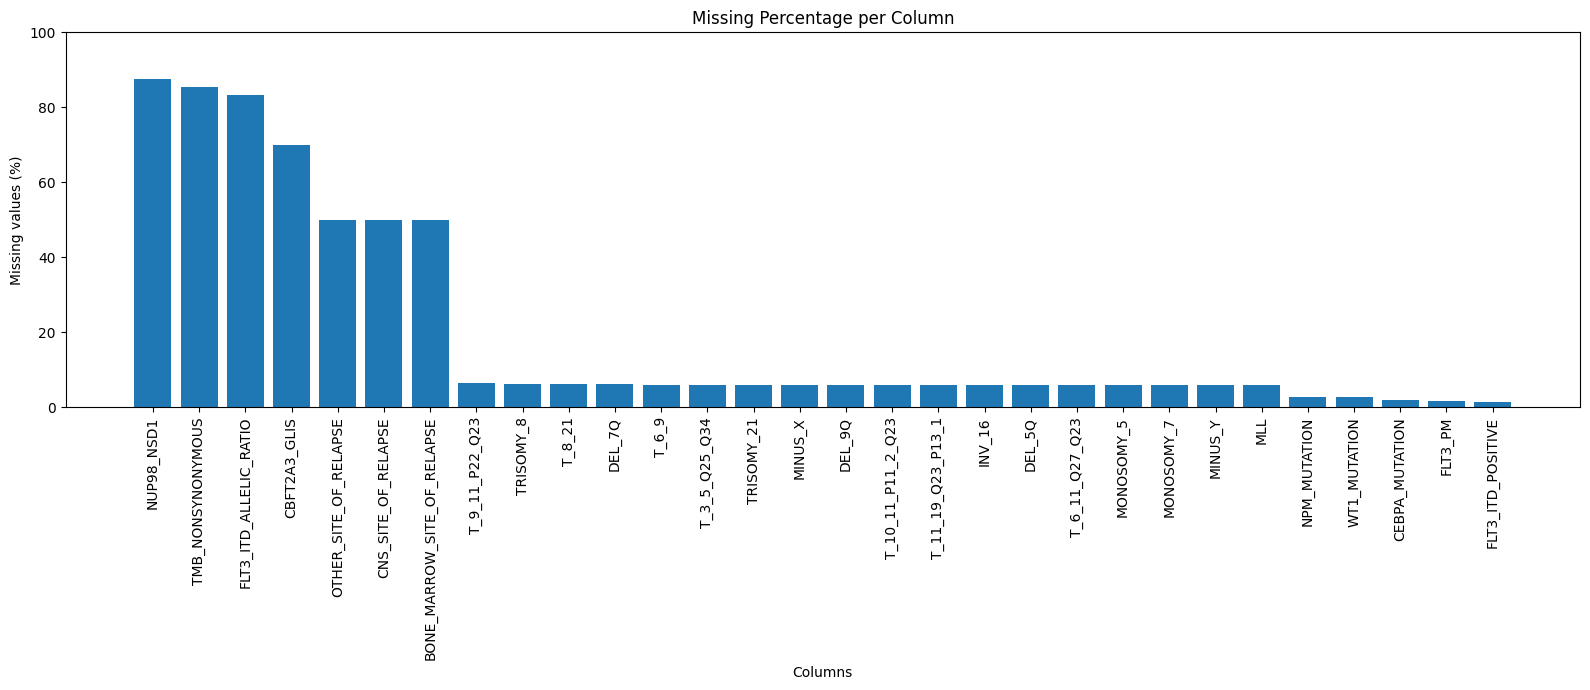

In [ ]:
# ------------------------------------------------------------
# 18) Plot missing percentage per column
# ------------------------------------------------------------

plot_data = missing_summary[
    missing_summary["missing_count"] > 0
].copy()

plt.figure(figsize=(16, 7))

plt.bar(
    plot_data["column"],
    plot_data["missing_percentage"]
)

plt.ylabel("Missing values (%)")
plt.xlabel("Columns")
plt.title("Missing Percentage per Column")
plt.xticks(rotation=90)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


<Figure size 1600x800 with 0 Axes>

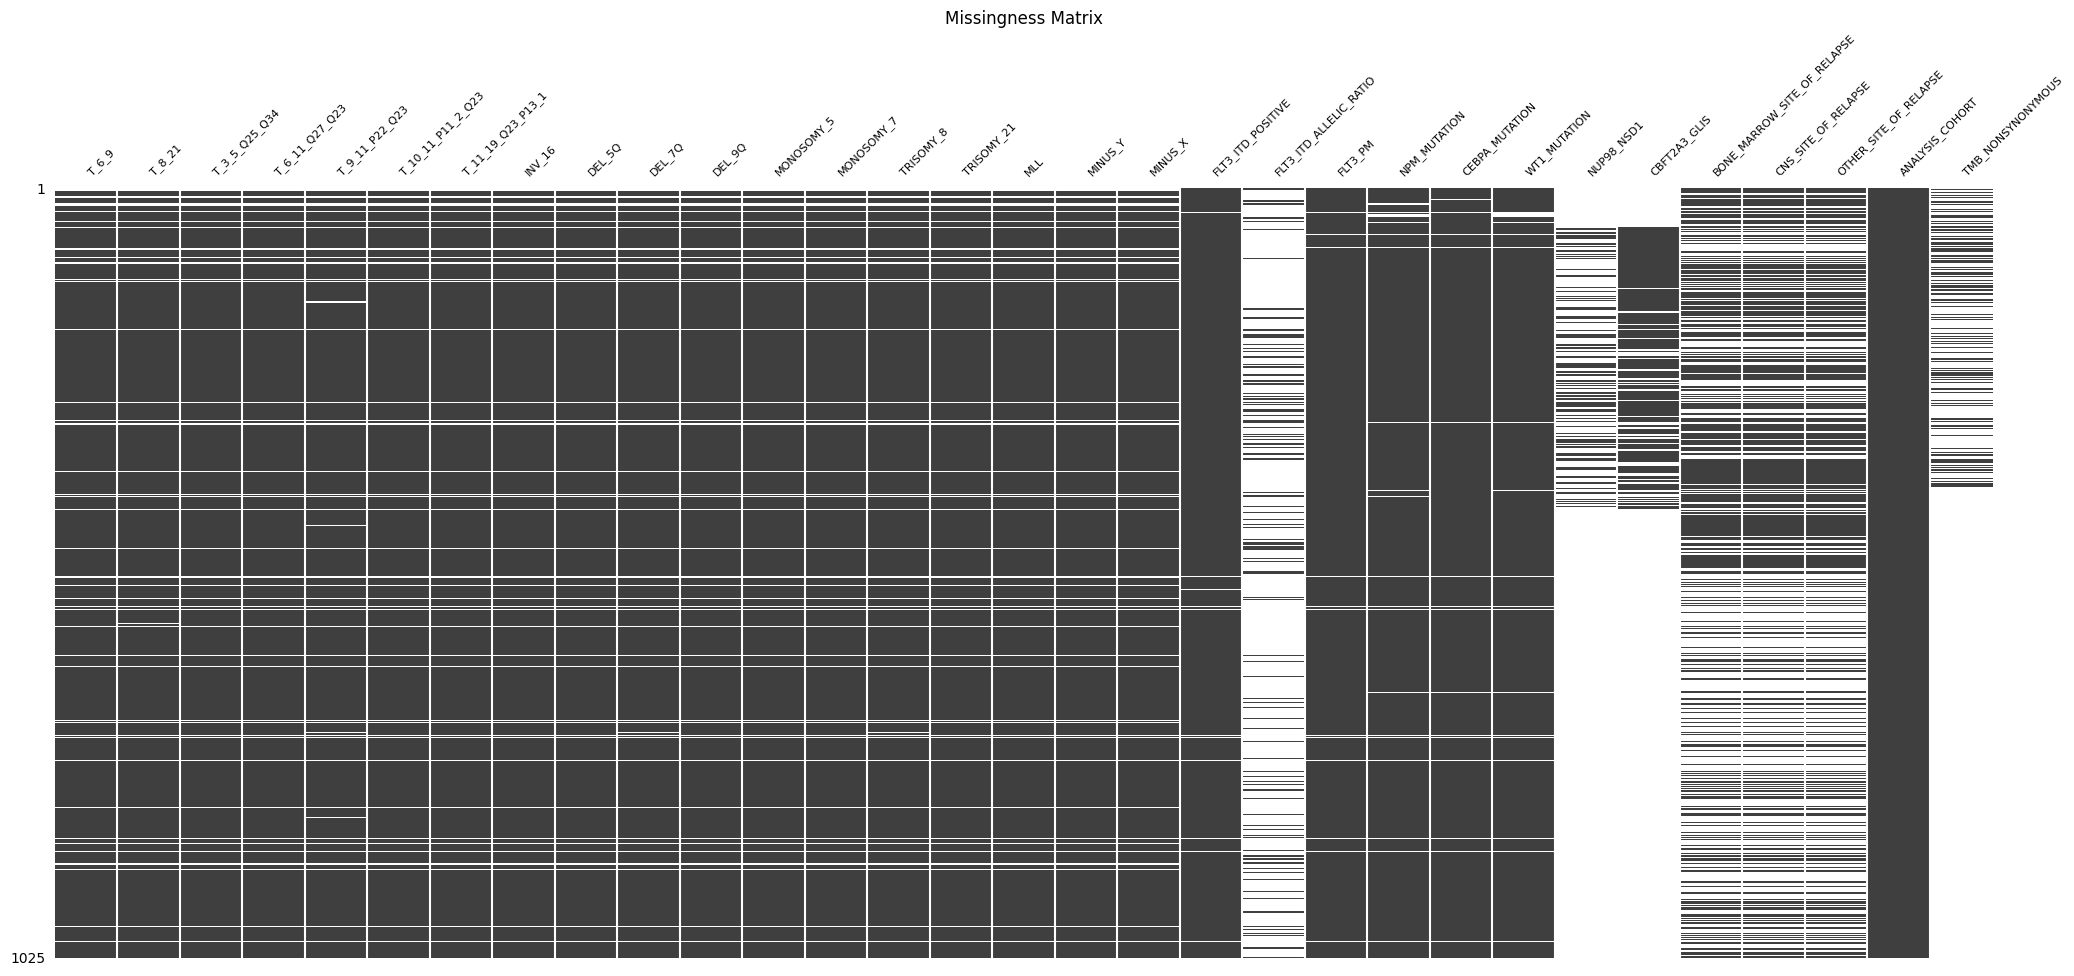

In [ ]:
# ------------------------------------------------------------
# 21) Missingness matrix
# ------------------------------------------------------------

# Exclude identifier and constant columns from visualizations.
# Constant columns do not contribute useful missingness patterns.

non_constant_analysis_columns = [
    column for column in analysis_columns
    if df[column].nunique(dropna=True) > 1
]

if len(non_constant_analysis_columns) > 0:

    plt.figure(figsize=(16, 8))

    msno.matrix(
        df[non_constant_analysis_columns],
        sparkline=False,
        fontsize=8
    )

    plt.title("Missingness Matrix")
    plt.show()

else:
    print(
        "Missingness matrix not generated: "
        "no suitable non-constant columns were found."
    )


<Figure size 1400x1000 with 0 Axes>

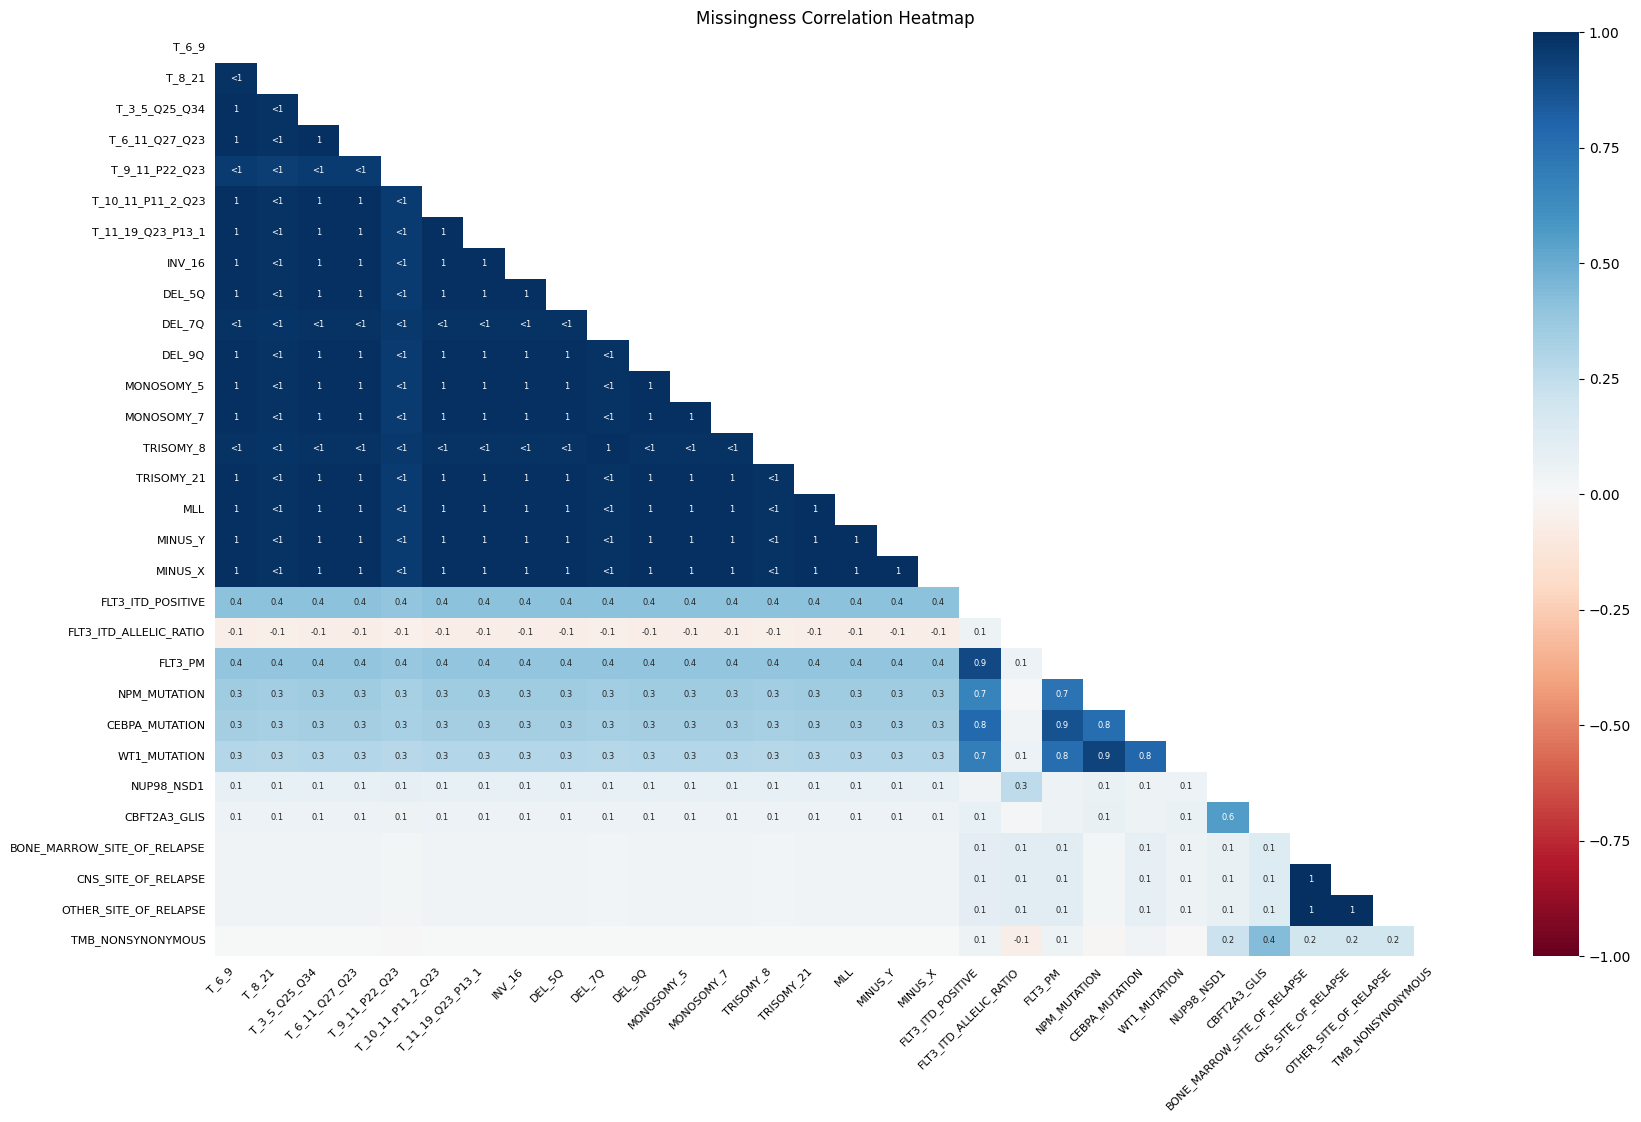

In [ ]:
# ------------------------------------------------------------
# 22) Missingness correlation heatmap
# ------------------------------------------------------------

# missingno.heatmap works best with columns that:
#   1. contain at least one missing value; and
#   2. are not completely missing.

heatmap_columns = [
    column for column in analysis_columns
    if (
        df[column].isna().sum() > 0
        and df[column].notna().sum() > 0
    )
]

if len(heatmap_columns) >= 2:

    plt.figure(figsize=(14, 10))

    msno.heatmap(
        df[heatmap_columns],
        fontsize=8
    )

    plt.title("Missingness Correlation Heatmap")
    plt.show()

else:
    print(
        "Missingness heatmap not generated: "
        "at least two partially missing columns are required."
    )



In [ ]:
# ------------------------------------------------------------
# 23) Check columns with excessive missingness
# ------------------------------------------------------------

# This is an analytical flag, not an automatic clinical decision.
# You may choose 50, 70, or 80 depending on:
#   - sample size;
#   - clinical relevance;
#   - whether the feature was systematically measured;
#   - the intended machine-learning model;
#   - advice from your supervisor.

missing_threshold = 25

excessive_missing_cols = missing_summary[
    missing_summary["missing_percentage"]
    >= missing_threshold
].copy()

print(
    f"\nColumns with at least "
    f"{missing_threshold}% missing values:"
)

display(excessive_missing_cols)


Columns with at least 25% missing values:


,column,dtype,non_missing_count,missing_count,missing_percentage,unique_non_missing_values
0,NUP98_NSD1,float64,127,898,87.609756,2
1,TMB_NONSYNONYMOUS,float64,150,875,85.365854,13
2,FLT3_ITD_ALLELIC_RATIO,float64,170,855,83.414634,88
3,CBFT2A3_GLIS,object,307,718,70.048780,3
4,OTHER_SITE_OF_RELAPSE,float64,512,513,50.048780,2
5,CNS_SITE_OF_RELAPSE,float64,512,513,50.048780,2
6,BONE_MARROW_SITE_OF_RELAPSE,float64,512,513,50.048780,2


In [ ]:
# ------------------------------------------------------------
# 24) Check constant and nearly constant columns
# ------------------------------------------------------------

# A constant column contains only one observed value.
# Such columns usually provide no predictive information.

constant_columns = [
    column for column in analysis_columns
    if df[column].nunique(dropna=True) <= 1
]

print("\nConstant or all-missing columns:")
print(constant_columns)


# A nearly constant column is dominated by one observed value.
# This does not automatically mean it should be removed.

near_constant_records = []

for column in analysis_columns:

    observed_values = df[column].dropna()

    if len(observed_values) == 0:
        continue

    normalized_counts = observed_values.value_counts(
        normalize=True
    )

    most_common_percentage = (
        normalized_counts.iloc[0] * 100
    )

    if most_common_percentage >= 95:

        near_constant_records.append({
            "column": column,
            "most_common_value":
                observed_values.value_counts().index[0],
            "most_common_percentage":
                most_common_percentage,
            "number_of_unique_values":
                observed_values.nunique()
        })

near_constant_summary = pd.DataFrame(
    near_constant_records
)

print("\nNearly constant columns:")
display(near_constant_summary)



Constant or all-missing columns:
['ONCOTREE_CODE', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'SOMATIC_STATUS']

Nearly constant columns:


,column,most_common_value,most_common_percentage,number_of_unique_values
0,T_6_9,0.0,98.546210,2
1,T_3_5_Q25_Q34,0.0,99.376947,2
2,T_6_11_Q27_Q23,0.0,98.130841,2
3,T_10_11_P11_2_Q23,0.0,97.715472,2
4,T_11_19_Q23_P13_1,0.0,97.403946,2
5,DEL_5Q,0.0,99.169263,2
6,DEL_7Q,0.0,97.713098,2
7,DEL_9Q,0.0,96.365524,2
8,MONOSOMY_5,0.0,99.896158,2
9,MONOSOMY_7,0.0,98.026999,2


In [ ]:
# ------------------------------------------------------------
# 25) Save the standardized but unreduced dataset
# ------------------------------------------------------------

# This version retains all columns.
# Only formatting and missing-value representations were cleaned.

df.to_csv(
    cleaned_output_path,
    index=False
)

print(
    "\nCleaned full dataset saved to:",
    cleaned_output_path
)



Cleaned full dataset saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/CLEANED_clinical_sample_missing_values_standardized.csv


In [ ]:
# ------------------------------------------------------------
# 26) Define clinically important columns to protect
# ------------------------------------------------------------

# Add columns here only after considering their biological and
# clinical relevance.
#
# These columns will not be dropped even when they exceed the
# missingness threshold.
#
# Example:
#
# important_cols_to_keep = [
#     "FLT3_ITD_POSITIVE",
#     "FLT3_ITD_ALLELIC_RATIO",
#     "NPM_MUTATION",
#     "CEBPA_MUTATION"
# ]
#
# The default is empty so that the code does not make a clinical
# decision automatically.

important_cols_to_keep = [
    # "NUP98_NSD1",
    "FLT3_ITD_ALLELIC_RATIO",
    # "CBFT2A3_GLIS"
]


# Keep only protected columns that actually exist.
valid_important_cols = [
    column for column in important_cols_to_keep
    if column in df.columns
]

invalid_important_cols = [
    column for column in important_cols_to_keep
    if column not in df.columns
]

if invalid_important_cols:
    print(
        "\nWarning: These protected columns were not found:"
    )
    print(invalid_important_cols)


# ------------------------------------------------------------
# 27) Create the drop list
# ------------------------------------------------------------

cols_to_drop = excessive_missing_cols[
    "column"
].tolist()

# Never drop identifiers during this missingness-reduction step.
cols_to_drop = [
    column for column in cols_to_drop
    if column not in identifier_columns
]

# Remove clinically protected columns from the drop list.
cols_to_drop = [
    column for column in cols_to_drop
    if column not in valid_important_cols
]

print("\nColumns proposed for removal:")
print(cols_to_drop)

print("\nProtected clinical columns:")
print(valid_important_cols)


Columns proposed for removal:
['NUP98_NSD1', 'TMB_NONSYNONYMOUS', 'CBFT2A3_GLIS', 'OTHER_SITE_OF_RELAPSE', 'CNS_SITE_OF_RELAPSE', 'BONE_MARROW_SITE_OF_RELAPSE']

Protected clinical columns:
['FLT3_ITD_ALLELIC_RATIO']


In [ ]:
# ------------------------------------------------------------
# 28) Create reduced dataset
# ------------------------------------------------------------

df_reduced = df.drop(
    columns=cols_to_drop,
    errors="ignore"
)

print("\nOriginal standardized shape:", df.shape)
print("Reduced dataset shape:", df_reduced.shape)
print("Number of removed columns:", len(cols_to_drop))



Original standardized shape: (1025, 37)
Reduced dataset shape: (1025, 31)
Number of removed columns: 6


In [ ]:
# ------------------------------------------------------------
# 29) Save reduced dataset
# ------------------------------------------------------------

df_reduced.to_csv(
    reduced_output_path,
    index=False
)

print(
    "\nReduced dataset saved to:",
    reduced_output_path
)




Reduced dataset saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/REDUCED_clinical_sample_missingness_checked.csv


In [ ]:
# ------------------------------------------------------------
# 30) Final report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING DATA ANALYSIS COMPLETED")
print("=" * 60)

print("Original rows:", df.shape[0])
print("Original columns:", df.shape[1])
print("Reduced columns:", df_reduced.shape[1])

print(
    "Columns containing missing values:",
    columns_with_missing.shape[0]
)

print(
    f"Columns with >= {missing_threshold}% missingness:",
    excessive_missing_cols.shape[0]
)

print(
    "Columns removed:",
    len(cols_to_drop)
)

print(
    "Overall feature-level missingness:",
    f"{overall_missing_percentage:.2f}%"
)

print("\nGenerated files:")
print("1.", missing_summary_path)
print("2.", row_missingness_path)
print("3.", unusual_values_path)
print("4.", cleaned_output_path)
print("5.", reduced_output_path)


MISSING DATA ANALYSIS COMPLETED
Original rows: 1025
Original columns: 37
Reduced columns: 31
Columns containing missing values: 30
Columns with >= 25% missingness: 7
Columns removed: 6
Overall feature-level missingness: 17.05%

Generated files:
1. /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/sample_missingness_summary.csv
2. /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/sample_row_missingness_summary.csv
3. /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/sample_categorical_value_summary.csv
4. /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/CLEANED_clinical_sample_missing_values_standardized.csv
5. /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Sample/REDUCED_clinical_sample_missingness_checked.csv
